# Data Exploration Notebook

This notebook covers Step 1 of the RAG evaluation project: dataset setup, exploration, and quality analysis using modular helper functions from `src/`.

## Setup and Imports

In [5]:
from pathlib import Path
import sys
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Determine project root from notebook location
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Add project root to path for imports
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Change to project root
os.chdir(PROJECT_ROOT)

from src.utils import load_text_table, load_queries
from src.config import load_config

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 100)

## Load Configuration

In [6]:
# Load default configuration
config = load_config()

# Access config using .get() method instead of subscripting
PASSAGES_PATH = config.get('paths', 'passages')
QUERIES_PATH = config.get('paths', 'queries')
MILVUS_PATH = config.get('paths', 'milvus_db')
EVALUATION_QUERIES = config.get('retrieval', 'evaluation_queries')

print(f"Working directory: {os.getcwd()}")
print(f"Passages source: {PASSAGES_PATH}")
print(f"Queries source: {QUERIES_PATH}")
print(f"Milvus database: {MILVUS_PATH}")
print(f"Evaluation query count: {EVALUATION_QUERIES}")

Working directory: /path/to/rag-eval
Passages source: hf://datasets/rag-datasets/rag-mini-wikipedia/data/passages.parquet/part.0.parquet
Queries source: hf://datasets/rag-datasets/rag-mini-wikipedia/data/test.parquet/part.0.parquet
Milvus database: data/rag_wikipedia_mini.db
Evaluation query count: 100


## Load Datasets

Load passages and queries from the RAG Mini Wikipedia dataset using modular helper functions.

In [7]:
# Load full passages dataset
passages = load_text_table(PASSAGES_PATH, text_column='passage')
print(f"Loaded {len(passages):,} passages")
print(f"Columns: {list(passages.columns)}")
passages.head()

Loaded 3,200 passages
Columns: ['passage']


,passage
0,"Uruguay (official full name in ; pron. , Eastern Republic of Uruguay) is a country located in..."
1,"It is bordered by Brazil to the north, by Argentina across the bank of both the Uruguay River to..."
2,Montevideo was founded by the Spanish in the early 18th century as a military stronghold. Urugua...
3,The economy is largely based in agriculture (making up 10% of the GDP and the most substantial e...
4,"According to Transparency International, Uruguay is the second least corrupt country in Latin Am..."


In [8]:
# Load queries dataset
queries = load_queries(QUERIES_PATH)
print(f"Loaded {len(queries):,} queries")
print(f"Columns: {list(queries.columns)}")
queries.head()

Loaded 918 queries
Columns: ['question', 'answer']


,question,answer
0,Was Abraham Lincoln the sixteenth President of the United States?,yes
1,Did Lincoln sign the National Banking Act of 1863?,yes
2,Did his mother die of pneumonia?,no
3,How many long was Lincoln's formal education?,18 months
4,When did Lincoln begin his political career?,1832


## Data Quality Analysis

In [9]:
# Passage length statistics
passages['passage_length'] = passages['passage'].str.len()
passages['passage_words'] = passages['passage'].str.split().str.len()

print("\nPassage Length Statistics:")
print(passages[['passage_length', 'passage_words']].describe())

# Check for missing or empty passages
null_passages = passages['passage'].isna().sum()
empty_passages = (passages['passage'].str.strip() == '').sum()
print(f"\nNull passages: {null_passages}")
print(f"Empty passages: {empty_passages}")


Passage Length Statistics:
       passage_length  passage_words
count     3200.000000    3200.000000
mean       389.712500      62.103750
std        348.403322      55.422049
min          1.000000       1.000000
25%        107.750000      17.000000
50%        299.000000      48.000000
75%        574.000000      92.000000
max       2515.000000     425.000000

Null passages: 0
Empty passages: 0


In [10]:
# Query length statistics
queries['question_length'] = queries['question'].str.len()
queries['question_words'] = queries['question'].str.split().str.len()

print("\nQuestion Length Statistics:")
print(queries[['question_length', 'question_words']].describe())

# Check for missing or empty questions
null_questions = queries['question'].isna().sum()
empty_questions = (queries['question'].str.strip() == '').sum()
print(f"\nNull questions: {null_questions}")
print(f"Empty questions: {empty_questions}")


Question Length Statistics:
       question_length  question_words
count       918.000000      918.000000
mean         53.083878        9.117647
std          28.483758        5.100655
min           4.000000        1.000000
25%          36.000000        6.000000
50%          47.000000        8.000000
75%          61.000000       11.000000
max         252.000000       48.000000

Null questions: 0
Empty questions: 0


## Visualizations

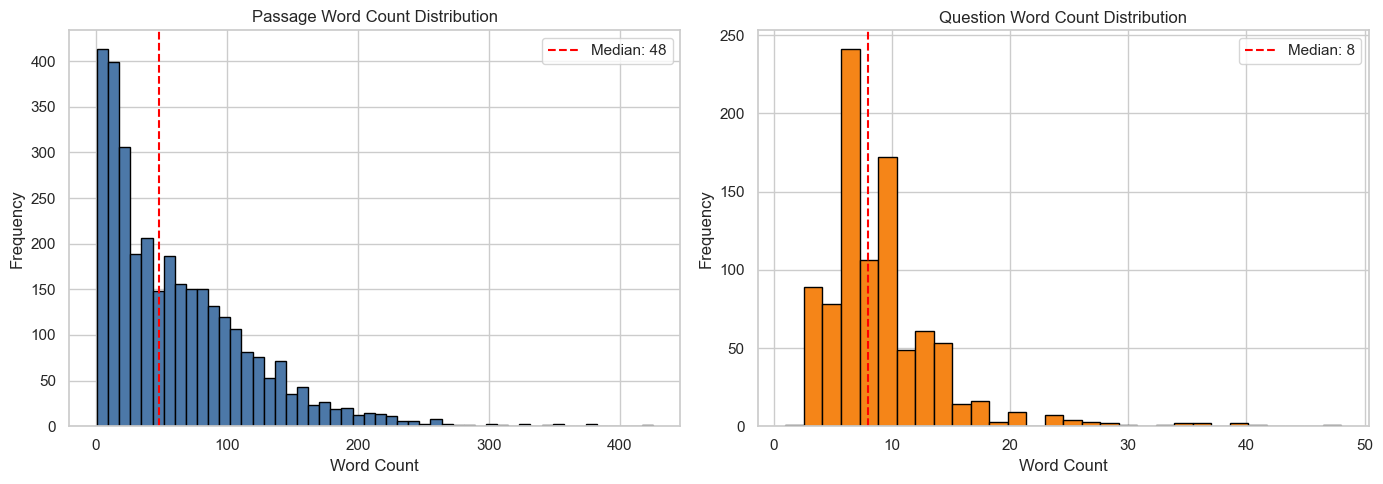

In [11]:
# Passage length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(passages['passage_words'], bins=50, color='#4C78A8', edgecolor='black')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Passage Word Count Distribution')
axes[0].axvline(passages['passage_words'].median(), color='red', linestyle='--', label=f'Median: {passages["passage_words"].median():.0f}')
axes[0].legend()

axes[1].hist(queries['question_words'], bins=30, color='#F58518', edgecolor='black')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Question Word Count Distribution')
axes[1].axvline(queries['question_words'].median(), color='red', linestyle='--', label=f'Median: {queries["question_words"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Sample Data Inspection

In [12]:
# Display random passage samples
print("Sample Passages:\n")
for idx, row in passages.sample(3, random_state=42).iterrows():
    print(f"[Passage {idx}]")
    print(f"Length: {row['passage_words']} words")
    print(f"Text: {row['passage'][:200]}...\n")

Sample Passages:

[Passage 2384]
Length: 86 words
Text: In some beetles, the ability to fly has been lost. These include the ground beetles (family Carabidae) and some "true weevils" (family Curculionidae), but also some desert and cave-dwelling species of...

[Passage 2538]
Length: 50 words
Text: The name "Qatar" may derive from the same Arabic root as qatura which means "to exude."  The word Qatura traces to the Arabic qatran meaning "tar" or "resin", which relates to the country's rich resou...

[Passage 2176]
Length: 101 words
Text: President Woodrow Wilson articulated what became known as the Fourteen Points before Congress on January 8, 1918.  The Points were the only war aims clearly expressed by any belligerent nation and thu...



In [13]:
# Display random query samples
print("Sample Questions:\n")
for idx, row in queries.sample(5, random_state=42).iterrows():
    print(f"[Query {idx}]")
    print(f"Question: {row['question']}")
    if 'answers' in row and row['answers']:
        print(f"Answer(s): {row['answers']}")
    print()

Sample Questions:

[Query 668]
Question: What is actually black in color?

[Query 30]
Question: When did he become a professor?

[Query 377]
Question: What does "Era of Good Feelings" refers to?

[Query 535]
Question: Does the state court rule on the conformity of laws?

[Query 807]
Question: What do turles use to breathe in the water?



## Evaluation Subset Selection

In [14]:
# Select evaluation subset (first N queries as specified in config)
eval_queries = queries.head(EVALUATION_QUERIES).copy()
print(f"\nSelected {len(eval_queries)} queries for evaluation")
print(f"Question word count range: {eval_queries['question_words'].min():.0f} - {eval_queries['question_words'].max():.0f}")
print(f"Median question length: {eval_queries['question_words'].median():.0f} words")


Selected 100 queries for evaluation
Question word count range: 3 - 23
Median question length: 8 words


## Summary

This notebook has:
1. Loaded the RAG Mini Wikipedia dataset using modular helper functions
2. Analyzed passage and query statistics
3. Visualized length distributions
4. Inspected sample data for quality
5. Selected the evaluation subset

**Next Steps:**
- Proceed to `complete_analysis.ipynb` for full pipeline implementation
- Or use `system_evaluation.ipynb` for smoke testing the modular pipeline
- Or use `final_analysis.ipynb` for results visualization